In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context

In [2]:
adata_loop2 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2p5/replicate/adata_500k.h5ad")

In [3]:
adata_loop2.obs.columns

Index(['experiment_number', 'replicate', 'date', 'cytometer',
       'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts',
       'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]',
       'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]',
       'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]',
       'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]',
       'source_cell_phenotype', 'total_count_beads',
       'counts_source_cell_phenotype', 'days_of_culture', 'plate',
       'absolute_number_multiplier_[2^n]', 'cytometer_id',
       'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width',
       'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width',
       'TIME', 'NA', 'AF Index', 'batch', '7-AAD'],
      dtype='object')

In [4]:
protocol_cols = ['gm-csf_[ng_ml]', 
                 'tpo_[ng_ml]', 
                 'sr1_[nm]',
                 'um171_[nm]', 
                 'um729_[µm]',
                 'scf_[ng_ml]',
                 'butyzamide_[nm]',
                 'retinoic_acid_[µm]', 
                 'ldl_[ng_ml]',
                 'il3_[ng_ml]', 
                 'o2_[%]',
                 'experiment_number']

In [5]:
obs_joint = adata_loop2.obs.loc[:, protocol_cols]

In [6]:
obs_joint = obs_joint.drop_duplicates()

In [7]:
obs_ery = obs_joint[obs_joint.experiment_number.isin(["241", "242", "249", "1178"])].astype(float)

In [8]:
obs_mgkpro = obs_joint[obs_joint.experiment_number.isin(["239", "240", "248", "210"])].astype(float)

In [9]:
obs_ery

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],experiment_number
270904-411,10.0,2.5,75.0,0.0,0.75,50.0,0.0,0.0,0.0,0.0,20.0,1178.0
42318-18,9.1,2.2,173.5,0.2,0.00,3.2,0.0,0.0,0.0,0.0,10.0,242.0
60586-13,10.4,2.7,235.0,0.8,0.00,1.3,0.0,0.0,0.0,0.0,10.0,241.0
58265-8,10.2,2.4,49.2,0.0,0.00,39.6,0.0,0.5,0.0,0.0,13.5,249.0


In [10]:
obs_mgkpro

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],experiment_number
124883-707,0.00,0.00,0.00,70.00,0.0,0.00,100.00,0.00,0.0,0.0,20.0,210.0
119845-10,5.94,0.44,12.45,0.00,0.0,47.13,5.03,1.27,0.0,0.0,10.0,240.0
30110-4,0.00,0.00,0.00,66.54,0.0,0.00,110.51,0.00,0.0,0.0,20.0,239.0
47950-1-1,6.83,0.55,21.97,0.26,0.0,50.36,5.63,1.21,0.0,0.0,10.0,248.0


In [11]:
# Column display name mapping
col_rename = {
    'gm-csf_[ng_ml]': 'GM-CSF\n(ng/ml)',
    'tpo_[ng_ml]': 'TPO\n(ng/ml)',
    'sr1_[nm]': 'SR1\n(nM)',
    'um171_[nm]': 'UM171\n(nM)',
    'um729_[μm]': 'UM729\n(µM)',
    'scf_[ng_ml]': 'SCF\n(ng/ml)',
    'butyzamide_[nm]': 'Butyzamide\n(nM)',
    'retinoic_acid_[μm]': 'Retinoic acid\n(µM)',
    'ldl_[ng_ml]': 'LDL\n(ng/ml)',
    'il3_[ng_ml]': 'IL-3\n(ng/ml)',
    'o2_[%]': 'O2\n(%)',
}

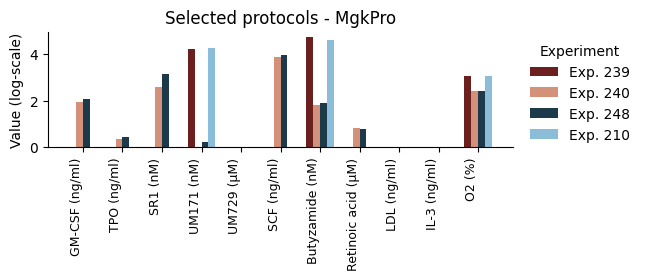

In [12]:
cols = [c for c in obs_mgkpro.columns if c != 'experiment_number']

col_rename = {}
for c in cols:
    label = c
    label = label.replace('gm-csf_[ng_ml]', 'GM-CSF (ng/ml)')
    label = label.replace('tpo_[ng_ml]', 'TPO (ng/ml)')
    label = label.replace('sr1_[nm]', 'SR1 (nM)')
    label = label.replace('um171_[nm]', 'UM171 (nM)')
    label = label.replace('scf_[ng_ml]', 'SCF (ng/ml)')
    label = label.replace('butyzamide_[nm]', 'Butyzamide (nM)')
    label = label.replace('ldl_[ng_ml]', 'LDL (ng/ml)')
    label = label.replace('il3_[ng_ml]', 'IL-3 (ng/ml)')
    label = label.replace('o2_[%]', 'O2 (%)')
    if 'um729' in c:
        label = 'UM729 (µM)'
    if 'retinoic_acid' in c:
        label = 'Retinoic acid (µM)'
    col_rename[c] = label

df_agg = obs_mgkpro.groupby('experiment_number')[cols].mean()
df_agg = df_agg.rename(columns=col_rename)
df_log = np.log1p(df_agg)

# Reorder so 210 is last — cast index to int for safe comparison
df_log.index = df_log.index.astype(int)
order = [idx for idx in df_log.index if idx != 210] + [210]
df_log = df_log.loc[order]

colors = ['#6B1F1F', '#D4917A', '#1C3A4A', '#8BBDD9'] # 210 last → dark red last
n_exp = len(df_log)
n_cond = len(df_log.columns)
x = np.arange(n_cond)
width = 0.7 / n_exp

fig, ax = plt.subplots(figsize=(6, 1.5))

for i, (exp_num, row) in enumerate(df_log.iterrows()):
    offset = (i - (n_exp - 1) / 2) * width
    ax.bar(x + offset, row.values, width, label=f'Exp. {exp_num}', color=colors[i % len(colors)])

ax.set_xticks(x)
ax.set_xticklabels(df_log.columns, rotation=90, ha='right', fontsize=9)
ax.set_ylabel('Value (log-scale)')
ax.set_title('Selected protocols - MgkPro')
ax.legend(title='Experiment', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# plt.tight_layout()
plt.savefig('mgkpro_protocols.svg', format='svg', bbox_inches='tight')
plt.show()

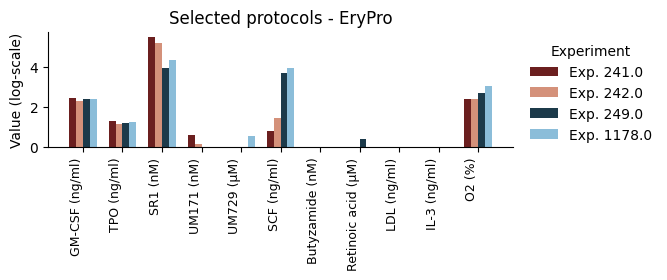

In [13]:
# Check actual column names first
cols = [c for c in obs_ery.columns if c != 'experiment_number']

# Build col_rename from actual column names
col_rename = {}
for c in cols:
    label = c
    label = label.replace('gm-csf_[ng_ml]', 'GM-CSF (ng/ml)')
    label = label.replace('tpo_[ng_ml]', 'TPO (ng/ml)')
    label = label.replace('sr1_[nm]', 'SR1 (nM)')
    label = label.replace('um171_[nm]', 'UM171 (nM)')
    label = label.replace('scf_[ng_ml]', 'SCF (ng/ml)')
    label = label.replace('butyzamide_[nm]', 'Butyzamide (nM)')
    label = label.replace('ldl_[ng_ml]', 'LDL (ng/ml)')
    label = label.replace('il3_[ng_ml]', 'IL-3 (ng/ml)')
    label = label.replace('o2_[%]', 'O2 (%)')
    if 'um729' in c:
        label = 'UM729 (µM)'
    if 'retinoic_acid' in c:
        label = 'Retinoic acid (µM)'
    col_rename[c] = label

# Aggregate by experiment_number
df_agg = obs_ery.groupby('experiment_number')[cols].mean()
df_agg = df_agg.rename(columns=col_rename)
df_log = np.log1p(df_agg)

colors = ['#6B1F1F', '#D4917A', '#1C3A4A', '#8BBDD9']
n_exp = len(df_log)
n_cond = len(df_log.columns)
x = np.arange(n_cond)
width = 0.7 / n_exp

fig, ax = plt.subplots(figsize=(6, 1.5))

for i, (exp_num, row) in enumerate(df_log.iterrows()):
    offset = (i - (n_exp - 1) / 2) * width
    ax.bar(x + offset, row.values, width, label=f'Exp. {exp_num}', color=colors[i % len(colors)])

ax.set_xticks(x)
ax.set_xticklabels(df_log.columns, rotation=90, ha='right', fontsize=9)
ax.set_ylabel('Value (log-scale)')
ax.set_title('Selected protocols - EryPro')
ax.legend(title='Experiment', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# plt.tight_layout()
plt.savefig('erypro_protocols.svg', format='svg', bbox_inches='tight')
plt.show()

## Plot heldout protocols 

In [14]:
adata_protocols = sc.AnnData(X=obs_joint.drop("experiment_number", axis=1).values.astype(float), 
                            obs=obs_joint)

In [15]:
# from sklearn.preprocessing import StandardScaler
# import scanpy as sc

# # Standardize columns
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(adata_protocols.X)

# # Replace the matrix
# adata_protocols.X = X_scaled

In [16]:
adata_protocols.obs["type"] = "Seen"

adata_protocols.obs.loc[adata_protocols.obs.experiment_number=="241", "type"] = "Seen EryPro" 
adata_protocols.obs.loc[adata_protocols.obs.experiment_number=="242", "type"] = "Seen EryPro" 
adata_protocols.obs.loc[adata_protocols.obs.experiment_number=="249", "type"] = "Heldout EryPro" 

adata_protocols.obs.loc[adata_protocols.obs.experiment_number=="239", "type"] = "Seen MgkPro" 
adata_protocols.obs.loc[adata_protocols.obs.experiment_number=="240", "type"] = "Seen MgkPro" 
adata_protocols.obs.loc[adata_protocols.obs.experiment_number=="248", "type"] = "Heldout MgkPro" 

In [17]:
sc.pp.log1p(adata_protocols)
sc.pp.pca(adata_protocols)

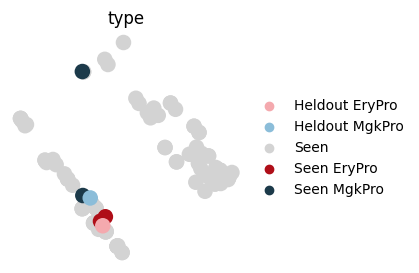

In [18]:
with rc_context({"figure.figsize": (3, 3)}):
    sc.pl.pca(
        adata_protocols,
        color="type",
        s=500,
        frameon=False, 
        palette={
            'Seen': '#D3D3D3',
            # EryPro: two shades of red (seen=darker, heldout=lighter)
            'Seen EryPro': '#af0e18',
            'Heldout EryPro': '#f4a9ae',
            # MgkPro: two shades of blue (seen=darker, heldout=lighter)
            'Seen MgkPro': '#1C3A4A',
            'Heldout MgkPro': '#8BBDD9',
        }
    )

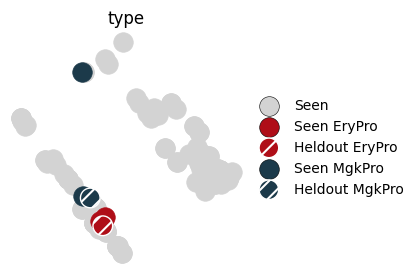

In [19]:
import matplotlib.pyplot as plt

with rc_context({"figure.figsize": (3, 3)}):
    plt.rcParams['hatch.linewidth'] = 1.5
    fig, ax = plt.subplots()

    pcs = adata_protocols.obsm["X_pca"]
    obs = adata_protocols.obs

    base_palette = {
        "Seen": "#D3D3D3",
        "Seen EryPro": "#af0e18",
        "Seen MgkPro": "#1C3A4A",
    }
    handles = []
    for cat, color in base_palette.items():
        mask = obs["type"] == cat
        ax.scatter(
            pcs[mask, 0], pcs[mask, 1],
            s=200, c=color, edgecolors=None, linewidths=0.4,
            zorder=2,
        )
        # Legend proxy: same style dot, drawn off-plot
        h = ax.scatter([], [], s=200, c=color, edgecolors="black", linewidths=0.4, label=cat)
        handles.append(h)

    heldout_palette = {
        "Heldout EryPro": {"fill": "#af0e18", "hatch": "white"},
        "Heldout MgkPro": {"fill": "#1C3A4A", "hatch": "white"},
    }
    for cat, colors in heldout_palette.items():
        mask = obs["type"] == cat
        ax.scatter(
            pcs[mask, 0], pcs[mask, 1],
            s=200, facecolors=colors["fill"], edgecolors=colors["hatch"],
            linewidths=1.0, hatch="//", zorder=5,
        )
        # Legend proxy: same hatched dot
        h = ax.scatter([], [], s=200, facecolors=colors["fill"], edgecolors=colors["hatch"],
                        linewidths=1.0, hatch="//", label=cat)
        handles.append(h)

    ax.set_frame_on(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("type")

    # Reorder handles to interleave Seen/Heldout pairs, matching your earlier legend order
    order = ["Seen", "Seen EryPro", "Heldout EryPro", "Seen MgkPro", "Heldout MgkPro"]
    by_label = {h.get_label(): h for h in handles}
    ordered_handles = [by_label[l] for l in order]

    ax.legend(handles=ordered_handles, labels=order, loc="center left",
              bbox_to_anchor=(1, 0.5), frameon=False)

    plt.savefig(
        "pca_type_heldout.png",
        dpi=600,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.show()

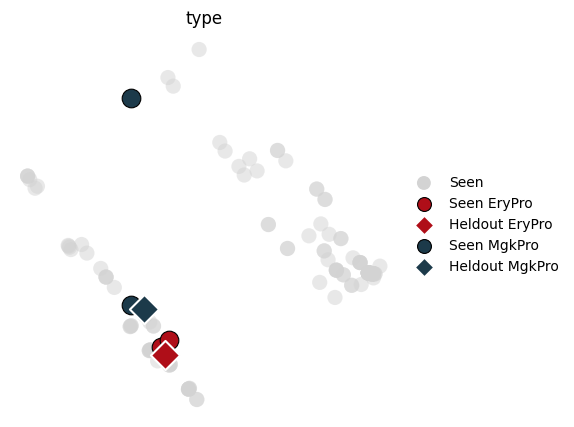

In [23]:
with rc_context({"figure.figsize": (5, 5)}):  # bigger canvas = more separation between points
    fig, ax = plt.subplots()
    pcs = adata_protocols.obsm["X_pca"]
    obs = adata_protocols.obs

    styles = {
        "Seen":            dict(color="#D3D3D3", marker="o", z=1, size=120,  alpha=0.5, edge="none",  lw=0),
        "Seen EryPro":     dict(color="#af0e18", marker="o", z=3, size=180, alpha=1.0, edge="black",  lw=0.8),
        "Heldout EryPro":  dict(color="#af0e18", marker="D", z=5, size=220, alpha=1.0, edge="white",  lw=1.5),
        "Seen MgkPro":     dict(color="#1C3A4A", marker="o", z=3, size=180, alpha=1.0, edge="black",  lw=0.8),
        "Heldout MgkPro":  dict(color="#1C3A4A", marker="D", z=5, size=220, alpha=1.0, edge="white",  lw=1.5),
    }

    handles = []
    for cat, s in styles.items():
        mask = obs["type"] == cat
        ax.scatter(
            pcs[mask, 0], pcs[mask, 1],
            s=s["size"], c=s["color"], marker=s["marker"], alpha=s["alpha"],
            edgecolors=s["edge"], linewidths=s["lw"], zorder=s["z"],
        )
        h = ax.scatter([], [], s=100, c=s["color"], marker=s["marker"],
                        edgecolors=s["edge"], linewidths=s["lw"], label=cat)
        handles.append(h)

    ax.set_frame_on(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("type")

    order = ["Seen", "Seen EryPro", "Heldout EryPro", "Seen MgkPro", "Heldout MgkPro"]
    by_label = {h.get_label(): h for h in handles}
    ordered_handles = [by_label[l] for l in order]
    ax.legend(handles=ordered_handles, labels=order, loc="center left",
              bbox_to_anchor=(1, 0.5), frameon=False)

    plt.savefig("pca_type_heldout.png", dpi=600, bbox_inches="tight", facecolor="white")
    plt.show()